#### Objective:
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.

#### Datasets :

#### Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset

#### Implementing Clustering Algorithms:

•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

#### Cluster Analysis and Interpretation:
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


#### Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

#### Evaluation and Performance Metrics:
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [1]:
#### import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors


In [2]:
### Load the Dataset
file = 'EastWestAirlines.xlsx'
df = pd.read_excel(file, sheet_name='data')



In [3]:
#### first few data
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
df.shape

(3999, 12)

In [5]:
### Initial Data Inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
#### Statistical review
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [7]:
### missing value
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [8]:
### checking duplicates value
df.duplicated().sum()

np.int64(0)

In [9]:
### Remove Irrelevant Column
df = df.drop(columns=['ID#'])


In [10]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [11]:
### Handle Missing Values
df = df.dropna()


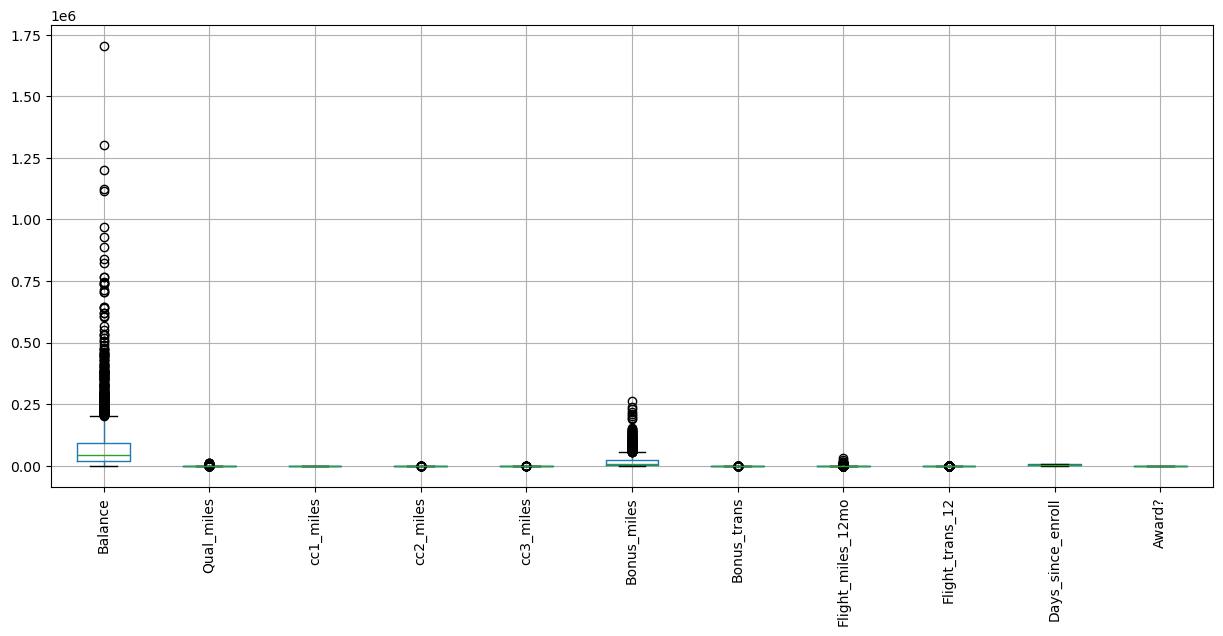

In [12]:
plt.figure(figsize=(15,6))
df.boxplot(rot=90)
plt.show()

In [13]:
#### outlier capping
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme=Q1-1.5*IQR
    Upper_Extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x:Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

In [14]:
### feature Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)


#### EDA

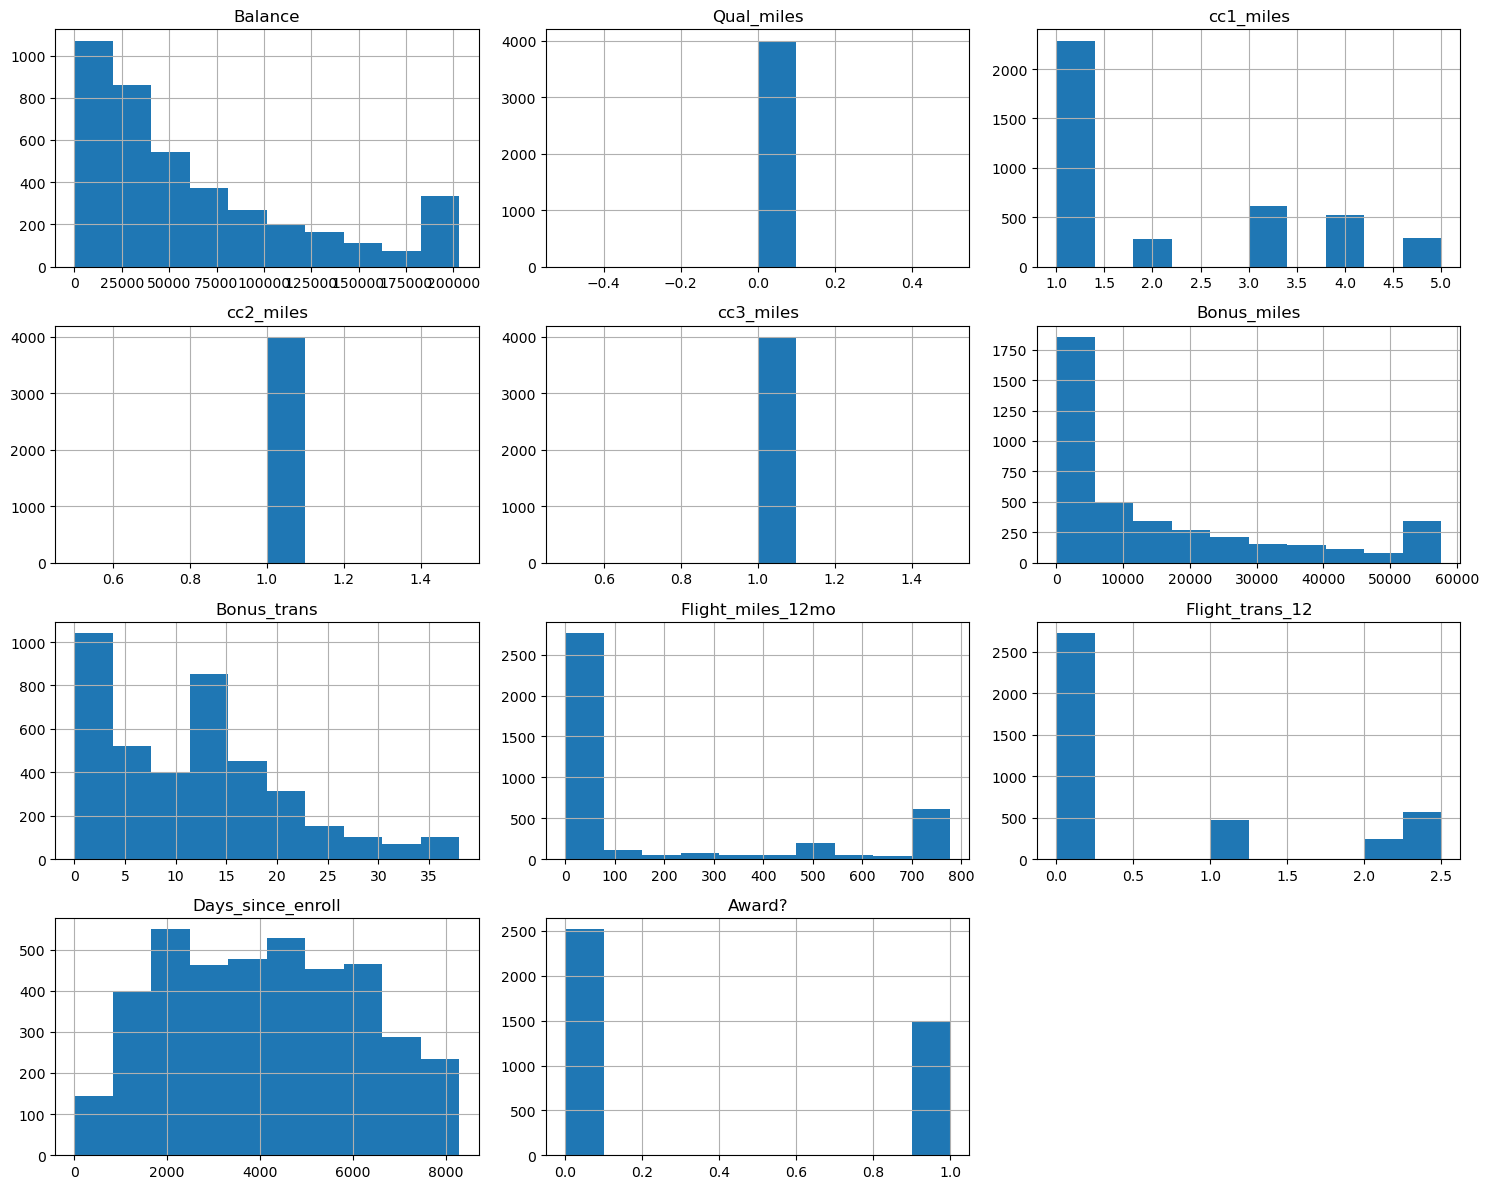

In [15]:
### Histogram
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()


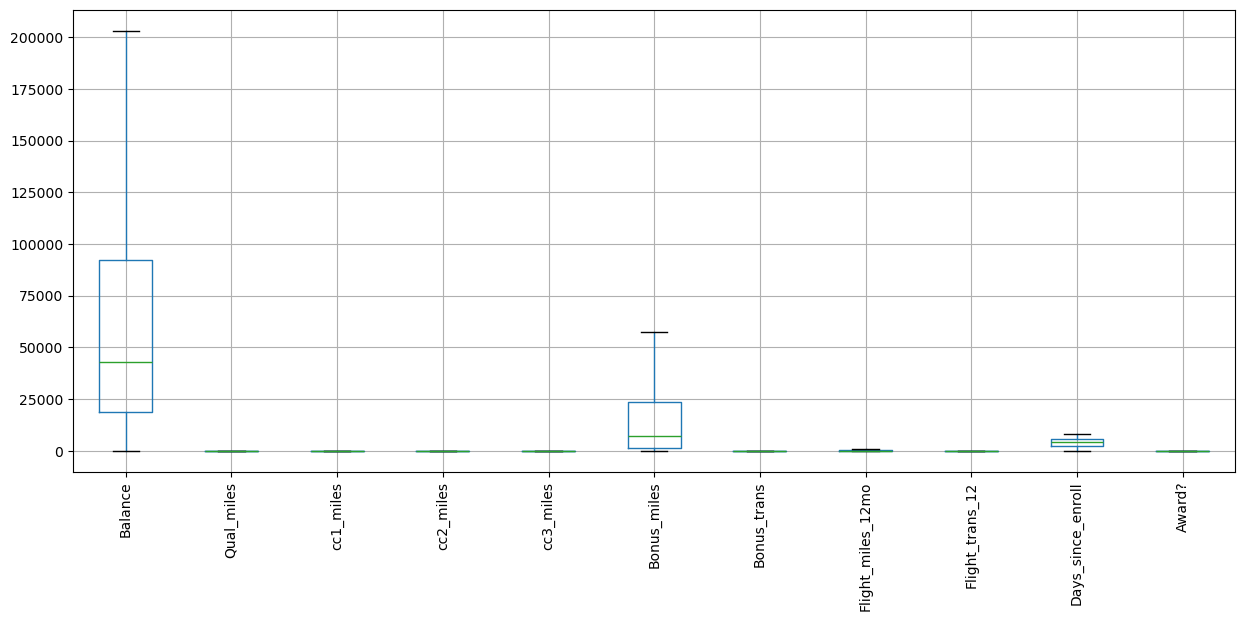

In [16]:
plt.figure(figsize=(15,6))
df.boxplot(rot=90)
plt.show()


### K-Means Clustering

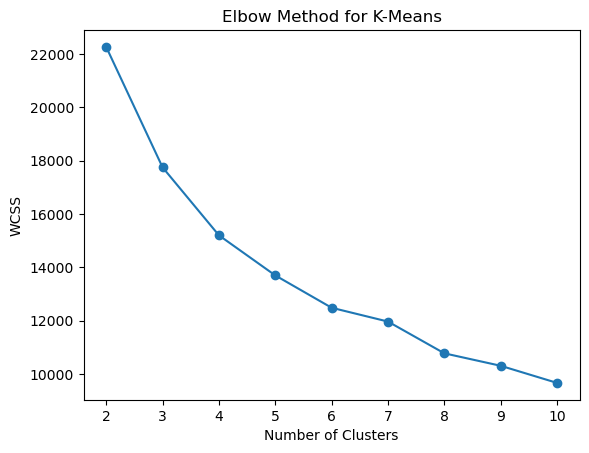

In [17]:
### Elbow Method to Find Optimal K
wcss = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    wcss.append(km.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for K-Means')
plt.show()


### Apply K-Means

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)


In [19]:
kmeans_silhouette = silhouette_score(df_scaled, kmeans_labels)
kmeans_silhouette


0.307123045013532

### DBSCAN Clustering

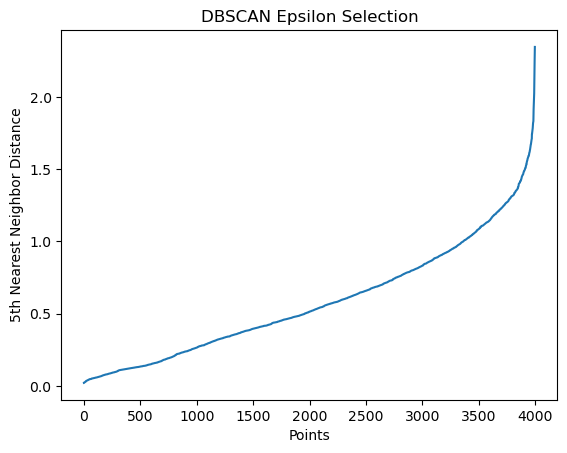

In [20]:
#### Estimate Epsilon Using Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances[:,4])

plt.plot(distances)
plt.xlabel('Points')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('DBSCAN Epsilon Selection')
plt.show()


### Apply DBSCAN

In [21]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)


##### Silhouette Score for DBSCAN

In [22]:
mask = dbscan_labels != -1
dbscan_silhouette = silhouette_score(df_scaled[mask], dbscan_labels[mask])
dbscan_silhouette


0.24359620653866218

In [24]:
#### Visualization Using PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

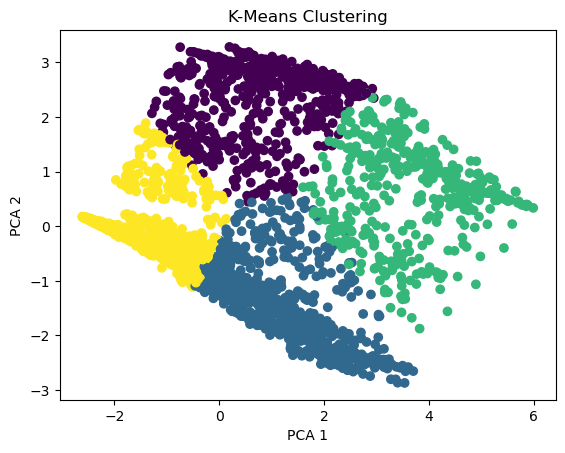

In [26]:
#### K-Means Visualization
plt.scatter(df_pca[:,0], df_pca[:,1], c=kmeans_labels)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering')
plt.show()


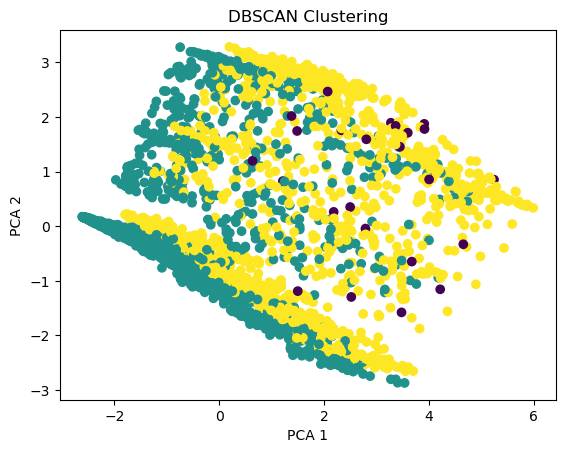

In [27]:
### DBSCAN Visualization
plt.scatter(df_pca[:,0], df_pca[:,1], c=dbscan_labels)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN Clustering')
plt.show()

### Cluster Interpretation

In [28]:
df['KMeans_Cluster'] = kmeans_labels
df['DBSCAN_Cluster'] = dbscan_labels

df.groupby('KMeans_Cluster').mean()


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,
0,76130.600081,0.0,1.212318,1.0,1.0,7674.886953,10.507293,646.921394,2.092382,4127.752026,0.513776,0.502431
1,88696.979360,0.0,3.454545,1.0,1.0,30234.419295,16.744898,26.167904,0.114100,4763.798701,0.517625,0.514842
2,125077.225686,0.0,4.024938,1.0,1.0,44366.632793,24.927681,638.718204,2.018703,5041.586035,0.802993,0.738155
3,32720.379926,0.0,1.129795,1.0,1.0,3420.064635,5.959538,15.007357,0.074619,3555.567525,0.149238,0.149238


#### Insights:

- High-balance, frequent flyers form distinct clusters

- Low-activity customers group separately

- DBSCAN identifies noise customers with unusual behavior

#### Final Conclusion

- K-Means performs well for structured customer segmentation

- DBSCAN handles noise and irregular patterns effectively

- Scaling and preprocessing significantly improve clustering results

- Combining EDA + clustering + evaluation provides meaningful insights